In [94]:
from pathlib import Path
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))

from utils.fancy_barplot import fancy_bars
from utils.fancy_hist import fancy_hist
from utils.triple_plot import normality_report
from utils.cat_num_dep import hub_pruebas_num_cat

from config import config

# Build the inital DataFrames

In [17]:
labels = pd.read_csv(config.LUNA25_LABELS)

In [16]:
data_nodules = pd.read_csv(
    config.NLST_CSVS / "nlst_780_ctab_idc_20210527.csv"
    ) # info del nodulo

In [15]:
data_patients = pd.read_csv(
    config.NLST_CSVS / "nlst_780_prsn_idc_20210527.csv"
    ) # info del paciente

In [ ]:
# filas = []
# for ruta in sorted(config.NODULE_METADATA_DIR.glob("*.npy")):
#     m = np.load(ruta, allow_pickle=True).item()

#     spacing   = np.asarray(m["spacing"], dtype=float)    # (z, y, x) en mm
#     origin    = np.asarray(m["origin"], dtype=float)     # (z, y, x) en mm
#     transform = np.asarray(m["transform"], dtype=float)  # 3x3

#     filas.append({
#         "AnnotationID": ruta.stem,
#         "spacing_z": spacing[0],
#         "spacing_y": spacing[1],
#         "spacing_x": spacing[2],
#         "anisotropia": spacing[0] / spacing[1],
#         "origin_z": origin[0],
#         "origin_y": origin[1],
#         "origin_x": origin[2],
#         "transform_identidad": np.allclose(transform, np.eye(3)),
#     })

# meta = pd.DataFrame(filas)

# print(f"anotaciones: {len(meta)}")
# print(f"claves del dict: {list(m.keys())}")
# print(f"transform no identidad: {(~meta.transform_identidad).sum()}")
# print()
# print(meta[["spacing_z", "spacing_y", "spacing_x", "anisotropia"]].describe())

# meta.head()

anotaciones: 6163
claves del dict: ['origin', 'spacing', 'transform']
transform no identidad: 3

         spacing_z    spacing_y    spacing_x  anisotropia
count  6163.000000  6163.000000  6163.000000  6163.000000
mean      1.948570     0.661145     0.661145     2.979692
std       0.415588     0.069552     0.069552     0.709682
min       0.500000     0.460938     0.460938     0.853333
25%       1.800000     0.609375     0.609375     2.633143
50%       2.000000     0.664062     0.664062     2.994152
75%       2.000000     0.703125     0.703125     3.447812
max       3.200001     0.976562     0.976562     6.277396


,AnnotationID,spacing_z,spacing_y,spacing_x,anisotropia,origin_z,origin_y,origin_x,transform_identidad
0,100012_1_19990102,2.0,0.585938,0.585938,3.413333,-154.399994,-173.808594,-70.605469,True
1,100012_1_20000102,2.0,0.546875,0.546875,3.657143,1158.699951,-165.351562,-82.867188,True
2,100035_1_19990102,2.5,0.585938,0.585938,4.266663,-272.500000,-31.713974,87.389259,True
3,100035_1_20000102,2.5,0.585938,0.585938,4.266663,-263.450012,-40.429600,90.075188,True
4,100035_1_20010102,2.5,0.585938,0.585938,4.266663,-291.859985,-17.651463,94.518944,True


# Cross information between nodules, patients and labels

## Verificar key de cruce

In [29]:
data_patients['gender'].unique()

array([1, 2])

In [22]:
data_nodules.columns

Index(['sct_ab_desc', 'sct_ab_num', 'sct_epi_loc', 'sct_long_dia',
       'sct_margins', 'sct_perp_dia', 'sct_pre_att', 'study_yr',
       'sct_slice_num', 'sct_found_after_comp', 'pid', 'dataset_version'],
      dtype='str')

In [30]:
labels['Gender']

0         Male
1       Female
2         Male
3         Male
4       Female
         ...  
6158    Female
6159    Female
6160    Female
6161      Male
6162      Male
Name: Gender, Length: 6163, dtype: str

In [24]:
print("Ejemplo PatientID en LUNA:", labels['PatientID'].head().tolist())
print("Ejemplo pid en NLST:", data_nodules['pid'].head().tolist())

Ejemplo PatientID en LUNA: [100570, 106364, 127302, 128899, 215816]
Ejemplo pid en NLST: [100002, 100002, 100002, 100004, 100004]


In [27]:
# 1. Copia de trabajo de labels
df_labels = labels.copy()

# 2. Asegurar que el ID del paciente esté en el mismo formato (entero o string limpio)
df_labels['pid'] = df_labels['PatientID'].astype(str).str.extract(r'(\d+)')[0].astype(int)
data_patients['pid'] = data_patients['pid'].astype(int)

# 3. Mapear 'Gender' de LUNA25 al formato de NLST si es necesario
# NLST suele usar 1 para Male y 2 para Female (o 'M' / 'F'). Ajustamos según corresponda:
gender_map = {'M': 1, 'F': 2, 'Male': 1, 'Female': 2, 1: 1, 2: 2}
df_labels['gender_norm'] = df_labels['Gender'].map(gender_map)
data_patients['gender_norm'] = data_patients['gender'].map(gender_map)

# 4. Hacer el merge por el identificador del paciente ('pid')
df_merged = pd.merge(
    df_labels[['PatientID', 'pid', 'Age_at_StudyDate', 'gender_norm']],
    data_patients[['pid', 'age', 'gender_norm']],
    on='pid',
    how='inner',
    suffixes=('_luna', '_nlst')
)

# 5. Evaluar coincidencias de Edad y Género
df_merged['match_age'] = df_merged['Age_at_StudyDate'] == df_merged['age']
df_merged['match_gender'] = df_merged['gender_norm_luna'] == df_merged['gender_norm_nlst']
df_merged['match_both'] = df_merged['match_age'] & df_merged['match_gender']

# 6. Reporte de resultados
total_coincidencias = len(df_merged)
coinciden_edad = df_merged['match_age'].sum()
coinciden_genero = df_merged['match_gender'].sum()
coinciden_ambos = df_merged['match_both'].sum()

print(f"Total de registros cruzados por ID: {total_coincidencias}")
print(f"Coinciden en Edad: {coinciden_edad} ({coinciden_edad / total_coincidencias * 100:.2f}%)")
print(f"Coinciden en Género: {coinciden_genero} ({coinciden_genero / total_coincidencias * 100:.2f}%)")
print(f"Coinciden en Ambos: {coinciden_ambos} ({coinciden_ambos / total_coincidencias * 100:.2f}%)")

# Mostrar las primeras filas con discrepancias (si existen)
discrepancias = df_merged[~df_merged['match_both']]
if not discrepancias.empty:
    print("\n--- Ejemplo de registros con discrepancias ---")
    print(discrepancias[['pid', 'Age_at_StudyDate', 'age', 'gender_norm_luna', 'gender_norm_nlst']].head())

Total de registros cruzados por ID: 6163
Coinciden en Edad: 2116 (34.33%)
Coinciden en Género: 6163 (100.00%)
Coinciden en Ambos: 2116 (34.33%)

--- Ejemplo de registros con discrepancias ---
      pid  Age_at_StudyDate  age  gender_norm_luna  gender_norm_nlst
2  127302                61   60                 1                 1
3  128899                64   62                 1                 1
7  215969                60   58                 1                 1
8  112235                65   64                 1                 1
9  112235                66   64                 1                 1


pequeñas discrepancias en la edad (p. ej., una diferencia de 1 o 2 años), esto se debe a que `Age_at_StudyDate` en LUNA25 registra la edad exacta del paciente en el momento en que se tomó la tomografía en un año específico (`study_yr` 0, 1 o 2), mientras que la columna `age` en `data_patients` registra la edad inicial de ingreso al ensayo (baseline age).

**El resultado confirma con un 100% de coincidencia en género que los pacientes mapeados por el pid son exactamente los mismos en ambas bases de datos.**

In [ ]:
# La edad del estudio debe ser igual o hasta 2 años mayor que la edad base
df_merged['valid_age_range'] = (
    (df_merged['Age_at_StudyDate'] >= df_merged['age']) &
    (df_merged['Age_at_StudyDate'] <= df_merged['age'] + 2)
)

porcentaje_valido = (df_merged['valid_age_range'].sum() / len(df_merged)) * 100
print(f"Coincidencia considerando rondas de estudio (0-2 años): {porcentaje_valido:.2f}%")

Coincidencia considerando rondas de estudio (0-2 años): 100.00%


## Hacer el cruce

In [ ]:
import pandas as pd

# 1. Preparar copias de trabajo
df_labels = labels.copy()
df_nodules = data_nodules.copy()
df_patients = data_patients.copy()

# 2. Normalizar el formato del ID del paciente ('pid')
df_labels['pid'] = df_labels['PatientID'].astype(str).str.extract(r'(\d+)')[0].astype(int)
df_nodules['pid'] = df_nodules['pid'].astype(int)
df_patients['pid'] = df_patients['pid'].astype(int)

# 3. Calcular el año de estudio (study_yr: 0, 1, 2) en LUNA25
# Se obtiene la edad base del paciente de forma temporal solo para los de LUNA
df_labels = df_labels.merge(df_patients[['pid', 'age']], on='pid', how='left')
df_labels['study_yr'] = df_labels['Age_at_StudyDate'] - df_labels['age']
df_labels.drop(columns=['age'], inplace=True)

df_nodules['study_yr'] = df_nodules['study_yr'].astype(int)

df_nodules['sct_long_dia'] = pd.to_numeric(df_nodules['sct_long_dia'], errors='coerce')

# 2. Dejar solo la anomalía de mayor diámetro por (pid, study_yr) un paciente
# puede tener varios nódulos, pero nos interesa el más grande de cada año
df_nodules_unique = df_nodules.sort_values('sct_long_dia', ascending=False).drop_duplicates(
    subset=['pid', 'study_yr']
)

# 4. PRIMER MERGE: LUNA25 + Características de Nódulos (NLST)
# how='left' conserva ÚNICAMENTE los registros de LUNA25
df_consolidado = pd.merge(
    df_labels,
    df_nodules_unique,
    on=['pid', 'study_yr'],
    how='left'
)

# 5. SEGUNDO MERGE: Agregar la información del Paciente (NLST)
# how='left' mantiene el filtro estricto de solo pacientes en LUNA25
df_consolidado = pd.merge(
    df_consolidado,
    df_patients,
    on='pid',
    how='left',
    suffixes=('', '_patient_df')
)

# Validaciones de control de calidad
pacientes_unicos_luna = df_labels['pid'].nunique()
pacientes_unicos_final = df_consolidado['pid'].nunique()

print(f"Pacientes únicos en LUNA25: {pacientes_unicos_luna}")
print(f"Pacientes únicos en el DataFrame final: {pacientes_unicos_final}")
print(f"Total de registros/filas en el dataset consolidado: {len(df_consolidado)}")

Pacientes únicos en LUNA25: 2120
Pacientes únicos en el DataFrame final: 2120
Total de registros/filas en el dataset consolidado: 6163


In [48]:
len(df_labels['PatientID'].unique())

2120

In [49]:
df_consolidado.head()

,PatientID,SeriesInstanceUID,StudyDate,CoordX,CoordY,CoordZ,LesionID,AnnotationID,NoduleID,label,...,can_scr,canc_rpt_link,dataset_version_patient_df,scr_days0,scr_days1,scr_days2,candx_days,canc_free_days,de_stag_7thed,gender_norm
0,100570,1.2.840.113654.2.55.32380467633296345717423514...,19990102,61.14,-163.28,-177.75,1,100570_1_19990102,100570_1,1,...,1,1,2011.02.03/05.12.21,37.0,NaN,NaN,69.0,0,110.0,1
1,106364,1.2.840.113654.2.55.16930993607533226779708566...,19990102,30.64,-95.96,-128.59,1,106364_1_19990102,106364_1,1,...,1,1,2011.02.03/05.12.21,0.0,NaN,NaN,73.0,0,110.0,2
2,127302,1.2.840.113654.2.55.13728437630416839550344528...,20000102,-82.53,-27.85,-209.46,1,127302_1_20000102,127302_1,1,...,1,1,2011.02.03/05.12.21,15.0,460.0,NaN,499.0,393,110.0,1
3,128899,1.2.840.113654.2.55.40415300708683206534849072...,20010102,-38.69,-8.78,-39.43,1,128899_1_20010102,128899_1,1,...,1,1,2011.02.03/05.12.21,14.0,366.0,891.0,1441.0,1091,400.0,1
4,215816,1.3.6.1.4.1.14519.5.2.1.7009.9004.241362276021...,19990102,32.89,-37.98,-100.04,1,215816_1_19990102,215816_1,1,...,1,1,2011.02.03/05.12.21,20.0,NaN,NaN,38.0,38,310.0,2


In [50]:
df_consolidado.shape

(6163, 63)

In [57]:
df_consolidado[df_consolidado['PatientID'] == 123244][['PatientID', 'study_yr', 'AnnotationID']]

,PatientID,study_yr,AnnotationID
6157,123244,1,123244_1_20000102
6158,123244,2,123244_1_20010102


In [54]:
df_consolidado

,PatientID,SeriesInstanceUID,StudyDate,CoordX,CoordY,CoordZ,LesionID,AnnotationID,NoduleID,label,...,can_scr,canc_rpt_link,dataset_version_patient_df,scr_days0,scr_days1,scr_days2,candx_days,canc_free_days,de_stag_7thed,gender_norm
0,100570,1.2.840.113654.2.55.32380467633296345717423514...,19990102,61.14,-163.28,-177.75,1,100570_1_19990102,100570_1,1,...,1,1,2011.02.03/05.12.21,37.0,NaN,NaN,69.0,0,110.0,1
1,106364,1.2.840.113654.2.55.16930993607533226779708566...,19990102,30.64,-95.96,-128.59,1,106364_1_19990102,106364_1,1,...,1,1,2011.02.03/05.12.21,0.0,NaN,NaN,73.0,0,110.0,2
2,127302,1.2.840.113654.2.55.13728437630416839550344528...,20000102,-82.53,-27.85,-209.46,1,127302_1_20000102,127302_1,1,...,1,1,2011.02.03/05.12.21,15.0,460.0,NaN,499.0,393,110.0,1
3,128899,1.2.840.113654.2.55.40415300708683206534849072...,20010102,-38.69,-8.78,-39.43,1,128899_1_20010102,128899_1,1,...,1,1,2011.02.03/05.12.21,14.0,366.0,891.0,1441.0,1091,400.0,1
4,215816,1.3.6.1.4.1.14519.5.2.1.7009.9004.241362276021...,19990102,32.89,-37.98,-100.04,1,215816_1_19990102,215816_1,1,...,1,1,2011.02.03/05.12.21,20.0,NaN,NaN,38.0,38,310.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6158,123244,1.2.840.113654.2.55.96785330641884045479008848...,20010102,50.88,55.09,1816.38,1,123244_1_20010102,123244_1,0,...,0,0,2011.02.03/05.12.21,45.0,411.0,775.0,NaN,2630,NaN,2
6159,104196,1.2.840.113654.2.55.67476228289351741200494264...,20000102,84.01,-94.42,1106.82,1,104196_1_20000102,104196_1,0,...,0,0,2011.02.03/05.12.21,0.0,497.0,931.0,NaN,2518,NaN,2
6160,104196,1.2.840.113654.2.55.24806580836056963319112187...,20010102,70.29,-85.76,1904.06,1,104196_1_20010102,104196_1,0,...,0,0,2011.02.03/05.12.21,0.0,497.0,931.0,NaN,2518,NaN,2
6161,204005,1.3.6.1.4.1.14519.5.2.1.7009.9004.291214500058...,19990102,128.81,11.64,-256.59,1,204005_1_19990102,204005_1,0,...,0,0,2011.02.03/05.12.21,0.0,377.0,720.0,NaN,2323,NaN,1


Dejar solo la anomalía de mayor diámetro por (pid, study_yr). Un paciente puede tener varios nódulos, pero nos interesa el más grande de cada año. Si bien es una estimación con sesgo, sirve como un primer vistazo al comportamiento de los nódulos posiblemente malignos (que suelen tener un diámetro mayor). Luego se calcularán dichas métricas directamente sobre las imágenes.

| Variable | Descripción | Significado de Codificaciones / Valores |
| :--- | :--- | :--- |
| **`CoordX`** | Coordenada del centro del nódulo en el eje X (mm). | *Coordenada continua en mm.* |
| **`CoordY`** | Coordenada del centro del nódulo en el eje Y (mm). | *Coordenada continua en mm.* |
| **`CoordZ`** | Coordenada del centro del nódulo en el eje Z (corte/profundidad). | *Coordenada continua o número de corte.* |
| **`LesionID`** | Identificador asignado a la lesión individual. | *Identificador único numérico/alfanumérico.* |
| **`AnnotationID`** | ID de la anotación radiológica realizada sobre el nódulo. | *Identificador único numérico/alfanumérico.* |
| **`NoduleID`** | Identificador único del nódulo evaluado. | *Identificador único numérico/alfanumérico.* |
| **`label`** | Etiqueta objetivo (Ground Truth). | • `0`: Benigno<br>• `1`: Maligno |
| **`Age_at_StudyDate`** | Edad del participante en la fecha exacta del examen. | *Valor numérico continuo (años).* |
| **`Gender`** | Género registrado en LUNA25. | *Categoría de género del participante.* |
| **`sct_long_dia`** | Diámetro mayor/longitudinal del nódulo (mm). | • *Numérico*: Diámetro mayor en milímetros para nódulos o masas no calcificadas $\ge 4$ mm.<br>• `.N`: No aplica (la descripción no corresponde a nódulo/masa $\ge 4$ mm).<br>• `.S`: Imposible de determinar. |
| **`sct_margins`** | Características de los bordes o márgenes del nódulo. | • `1`: Espiculado / Estrellado (*Spiculated/Stellate*)<br>• `2`: Suave / Liso (*Smooth*)<br>• `3`: Mal definido (*Poorly defined*)<br>• `9`: Imposible de determinar (*Unable to determine*)<br>• `.N`: No aplica |
| **`sct_pre_att`** | Atenuación/densidad predominante del nódulo. | • `1`: Tejido blando (*Soft Tissue*)<br>• `2`: Vidrio deslustrado (*Ground glass*)<br>• `3`: Mixto (*Mixed*)<br>• `4`: Fluido / Agua (*Fluid/water*)<br>• `6`: Grasa (*Fat*)<br>• `7`: Otro (*Other*)<br>• `9`: Imposible de determinar (*Unable to determine*)<br>• `.M`: Faltante / Ausente (*Missing*)<br>• `.N`: No aplica |
| **`sct_slice_num`** | Número de corte donde se ubica la mayor dimensión de la anomalía en la TC. | • *Numérico*: Número del corte de TC que contiene el mayor diámetro del nódulo.<br>• `999`: Valor faltante (*Missing*).<br>• `.N`: No aplica. |
| **`race`** | Raza o etnia del participante. | • `1`: Blanco (*White*)<br>• `2`: Negro o Afroamericano (*Black or African-American*)<br>• `3`: Asiático (*Asian*)<br>• `4`: Indígena americano o nativo de Alaska (*American Indian or Alaskan Native*)<br>• `5`: Nativo de Hawái u otra isla del Pacífico (*Native Hawaiian or Other Pacific Islander*)<br>• `6`: Más de una raza (*More than one race*)<br>• `7`: El participante se negó a responder (*Participant refused to answer*)<br>• `95`: Formulario de datos faltante - no se espera que se complete (*Missing data form - form is not expected to be completed*)<br>• `96`: Faltante - sin respuesta (*Missing - no response*)<br>• `98`: Faltante - formulario enviado pero dejado en blanco (*Missing - form was submitted and the item was left blank*)<br>• `99`: Desconocido / rechaza responder (*Unknown/ decline to answer*) |
| **`cigsmok`** | Historial y consumo acumulado de tabaco. | *Variable categórica o numérica indicadora de hábito de fumar.* |
| **`loclhil` / `locrhil`** | Cáncer localizado en hilio izquierdo / derecho. | • `0`: Ausente / No localizado en hilio<br>• `1`: Presente / Localizado en hilio |
| **`locllow` / `locrlow`** | Cáncer en lóbulo inferior izquierdo / derecho. | • `0`: Ausente en este lóbulo<br>• `1`: Localizado en el lóbulo inferior |
| **`loclup` / `locrup`** | Cáncer en lóbulo superior izquierdo / derecho. | • `0`: Ausente en este lóbulo<br>• `1`: Localizado en el lóbulo superior |
| **`locrmid`** | Cáncer en lóbulo medio derecho. | • `0`: Ausente en lóbulo medio derecho<br>• `1`: Localizado en lóbulo medio derecho |
| **`locunk`** | Localización pulmonar desconocida. | • `0`: Localización conocida<br>• `1`: Localización no especificada / desconocida |

## Analisis de la muestra

In [60]:
key_variables = [
    "CoordX",
    "CoordY",
    "CoordZ",
    "LesionID",
    "AnnotationID",
    "NoduleID",
    "label",
    "Age_at_StudyDate",
    "Gender",
    "sct_long_dia",
    "sct_margins",
    "sct_pre_att",
    "sct_slice_num",
    "race",
    "cigsmok",
    "loclhil",
    "locrhil",
    "locllow",
    "locrlow",
    "loclup",
    "locrup",
    "locrmid",
    "locunk",
]

In [61]:
df_consolidado = df_consolidado[key_variables]

### Analisis de calidad de la consolidación de datos

#### Nulos

In [71]:
(
    (df_consolidado.isnull().sum() / df_consolidado.shape[0])
    .to_frame(name="proporcion_nulos")
    .sort_values(by="proporcion_nulos", ascending=False)
)

,proporcion_nulos
sct_long_dia,0.017848
sct_margins,0.017037
sct_slice_num,0.017037
sct_pre_att,0.017037
CoordX,0.000000
CoordY,0.000000
CoordZ,0.000000
label,0.000000
NoduleID,0.000000
AnnotationID,0.000000


In [ ]:
df_consolidado.drop(
    columns=[
        'locrhil',
        'locllow',
        'locrlow',
        'loclup',
        'locrup',
        'locrmid',
        'locunk',
        'loclhil'], inplace=True)

Las variables locxxx en general tienen un 90% de valores nulos, por lo tanto se descarta su descripción en esta fase, por el contrario las variables de sct... (descriptores de forma del nodulo) solo tienen un 1% de valores nulos, por lo tanto se sigue considerando su analisis, variables de confusión como genero o raza si bien no son usadas por la red neuronal (que solo recibe imagenes) son descriptores utiles en esa fase de exploracióm y entendimiento de factores claves de malignidad en nodulos.

#### Duplicados

In [72]:
df_consolidado.duplicated().sum()

np.int64(0)

In [83]:
df_consolidado['sct_long_dia'].nunique()

59

## Analisis univariado de las variables numéricas y categóricas

In [74]:
# eliminar identificadores

df_consolidado.drop(columns=['LesionID', 'AnnotationID', 'NoduleID', 'LesionID'], inplace=True)

In [75]:
df_consolidado.info()

<class 'pandas.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CoordX            6163 non-null   float64
 1   CoordY            6163 non-null   float64
 2   CoordZ            6163 non-null   float64
 3   label             6163 non-null   int64  
 4   Age_at_StudyDate  6163 non-null   int64  
 5   Gender            6163 non-null   str    
 6   sct_long_dia      6053 non-null   float64
 7   sct_margins       6058 non-null   float64
 8   sct_pre_att       6058 non-null   float64
 9   sct_slice_num     6058 non-null   float64
 10  race              6163 non-null   int64  
 11  cigsmok           6163 non-null   int64  
dtypes: float64(7), int64(4), str(1)
memory usage: 577.9 KB


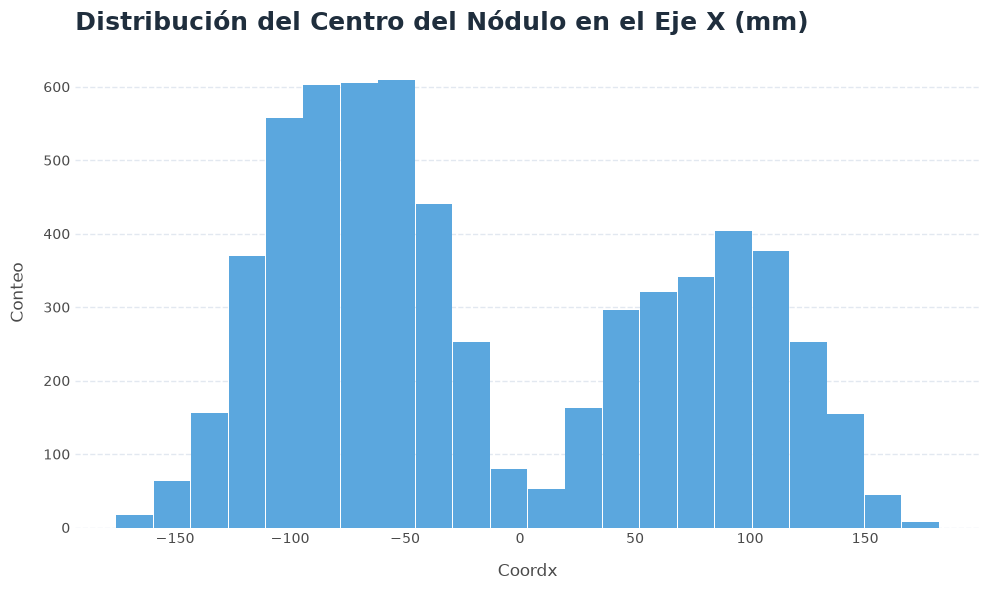

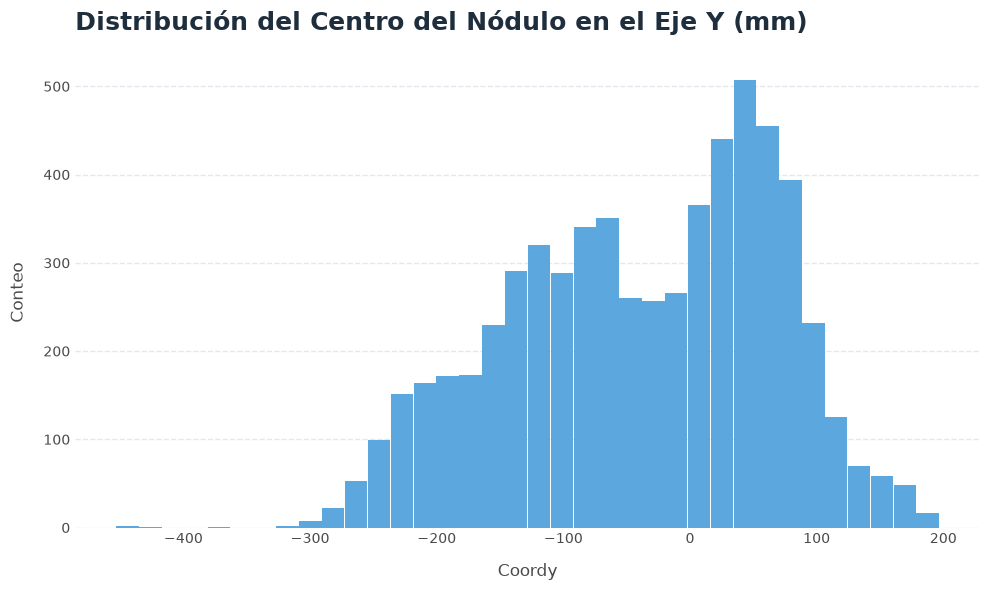

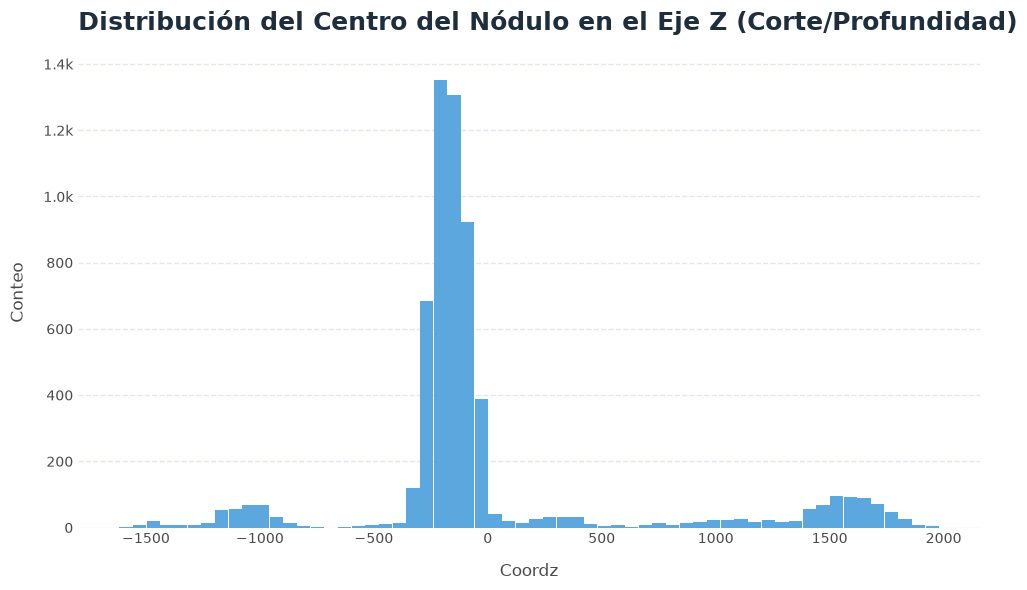

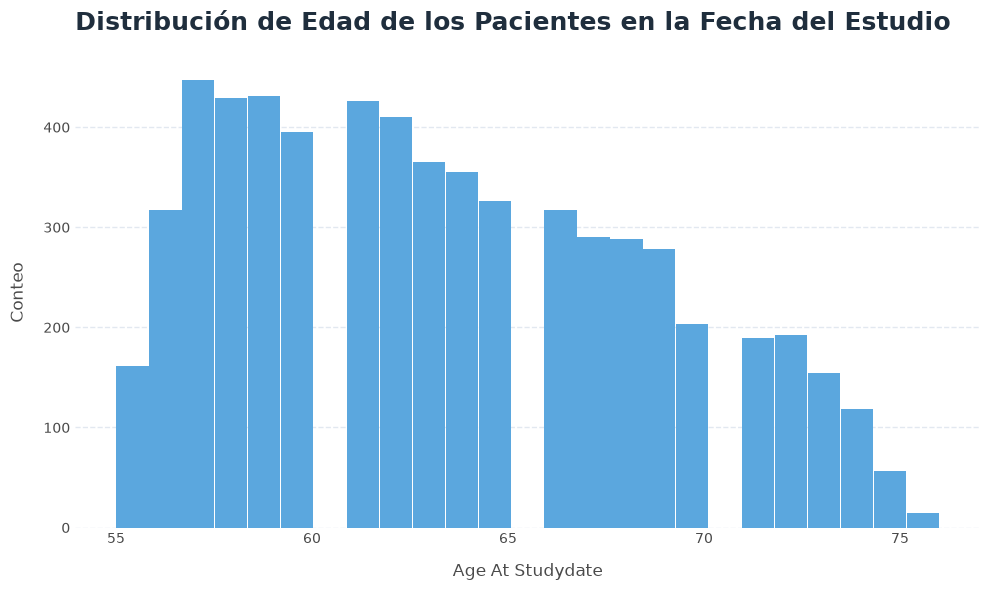

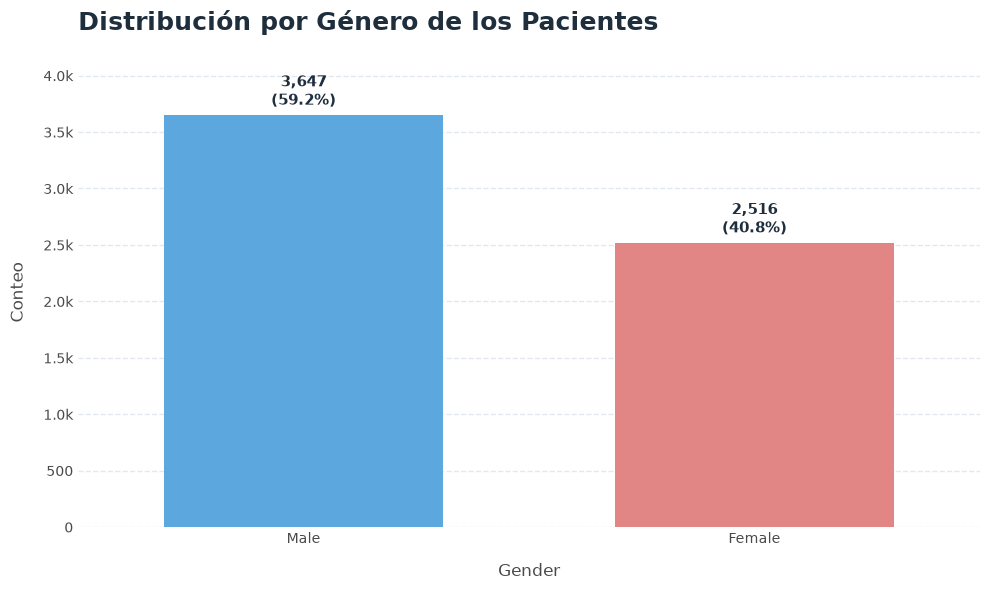

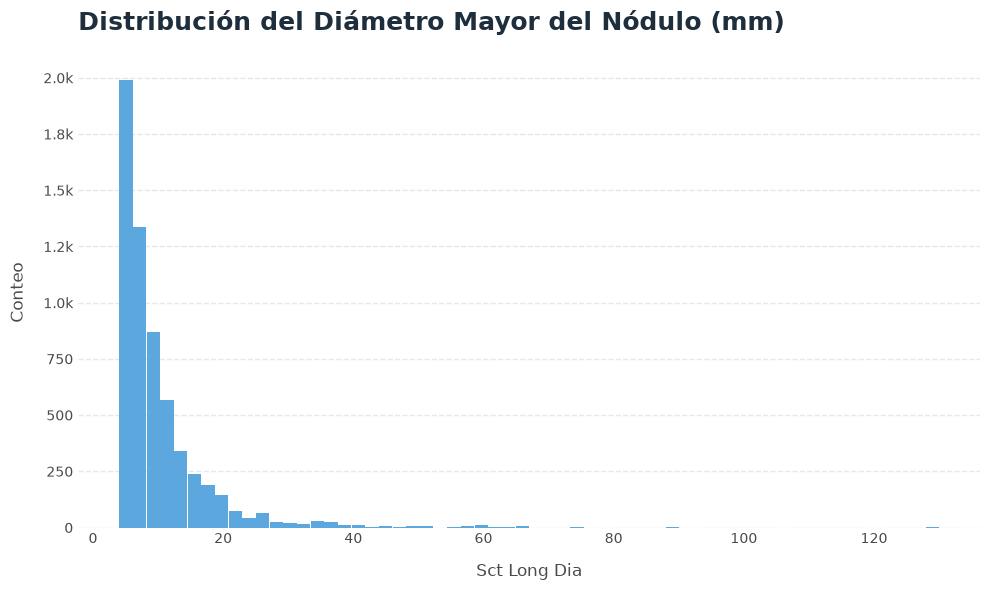

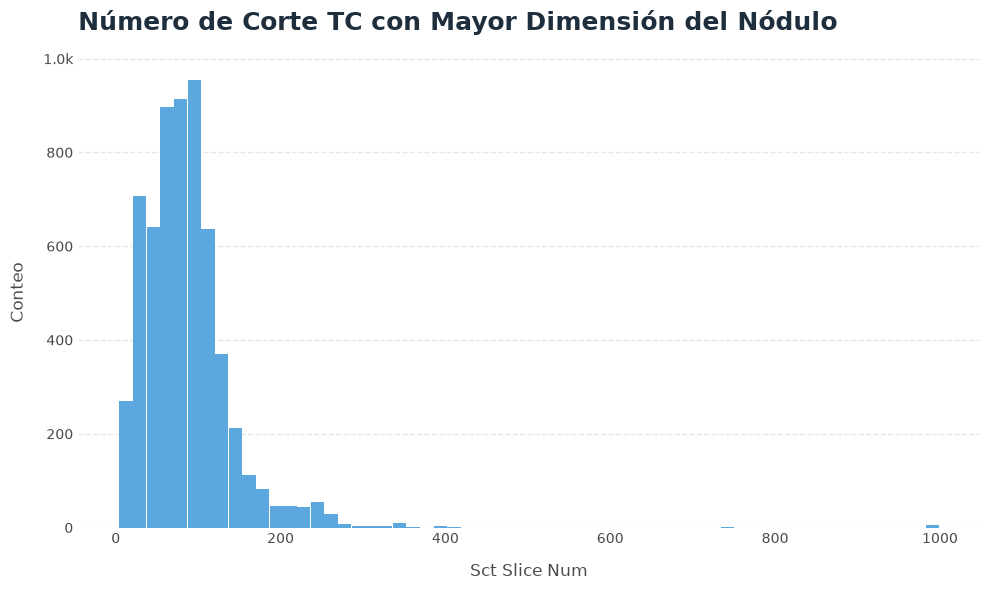

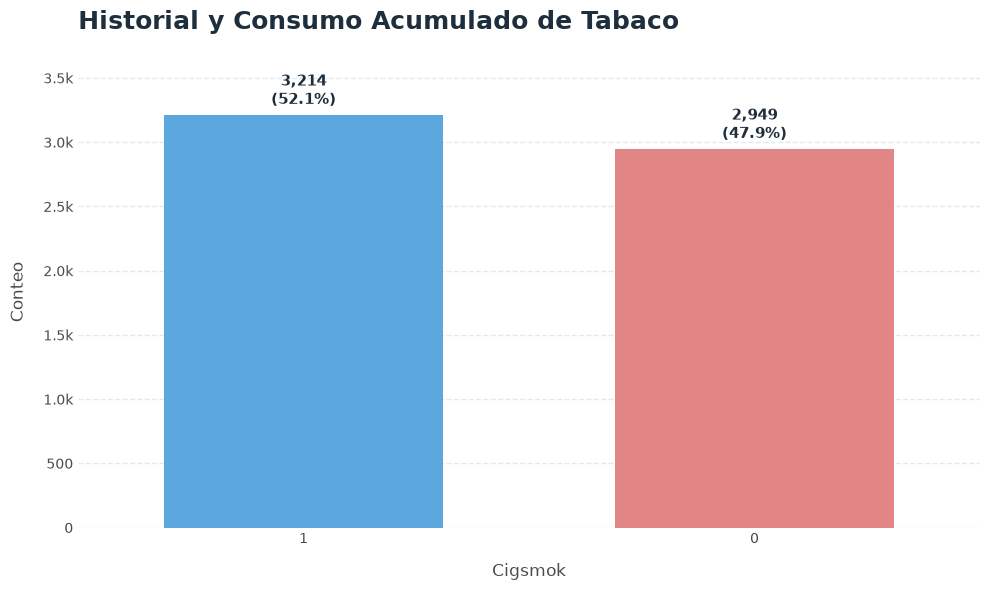

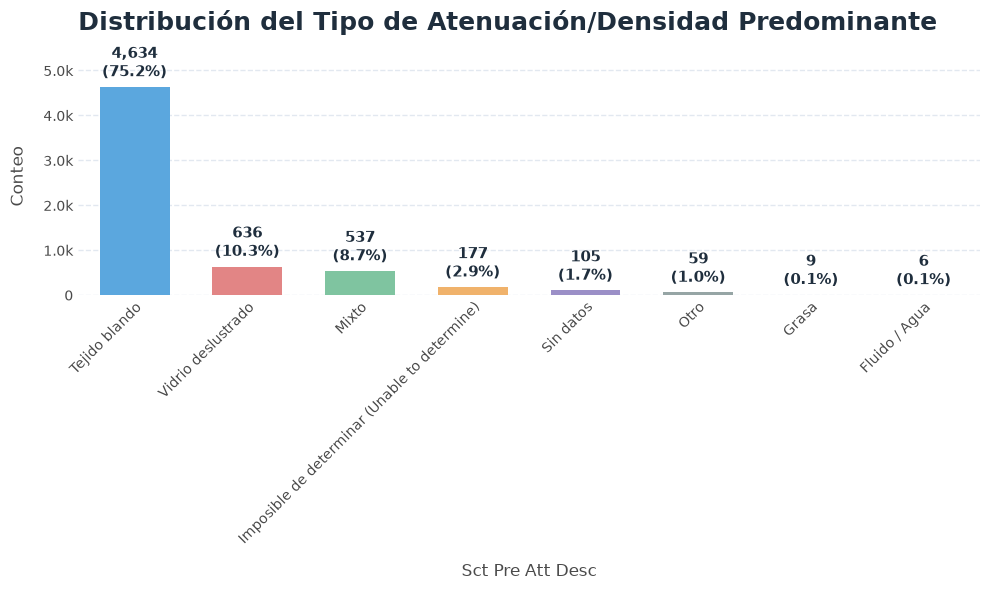

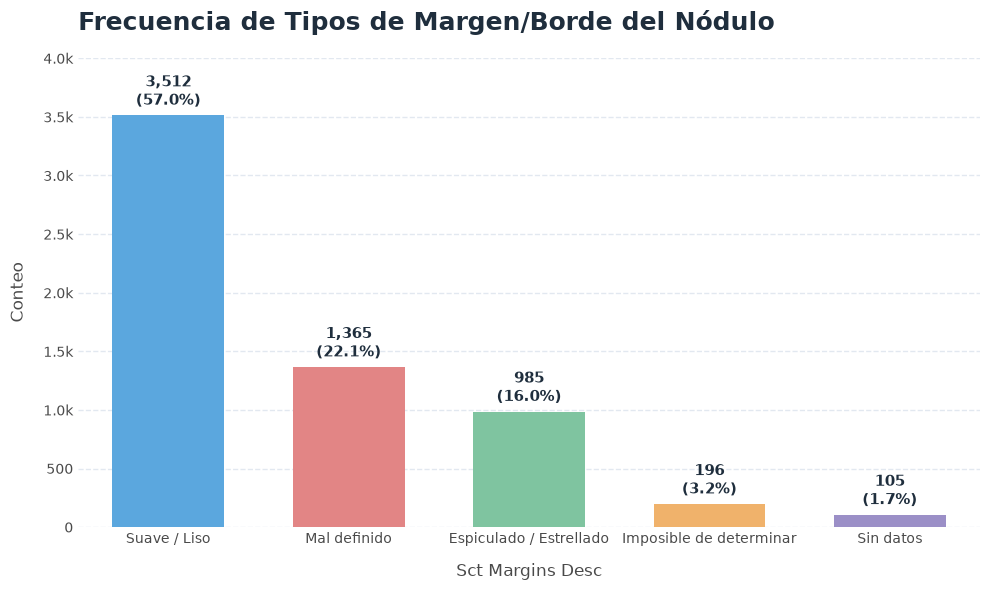

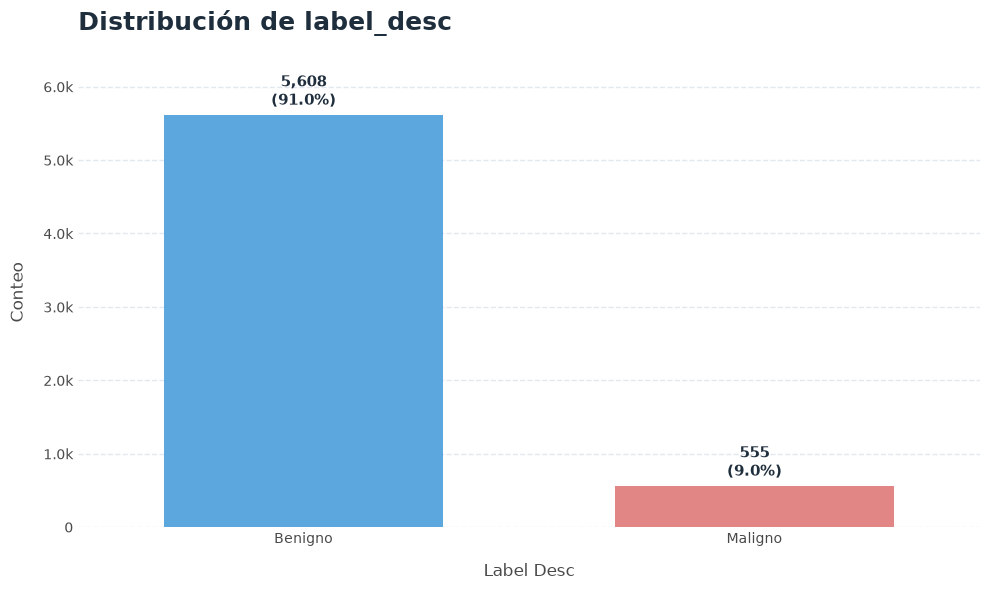

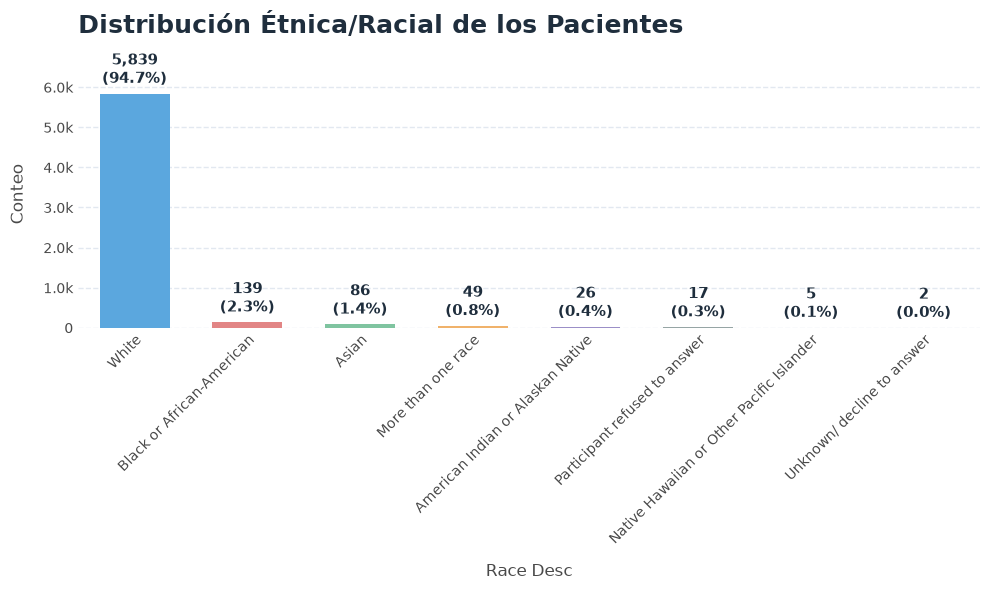

In [ ]:
# ================= DICIONARIOS DE MAPEO =================

sct_titles = {
    # Coordenadas y Ubicación
    "CoordX": "Distribución del Centro del Nódulo en el Eje X (mm)",
    "CoordY": "Distribución del Centro del Nódulo en el Eje Y (mm)",
    "CoordZ": "Distribución del Centro del Nódulo en el Eje Z (Corte/Profundidad)",
    "sct_slice_num": "Número de Corte TC con Mayor Dimensión del Nódulo",
    # Identificadores y Meta-información
    "LesionID": "Frecuencia de Lesiones Registradas",
    "AnnotationID": "Conteo de Anotaciones Radiológicas",
    "NoduleID": "Identificador de Nódulos Evaluados",
    "label": "Diagnóstico de Nódulo Pulmonar (Ground Truth: Benigno vs. Maligno)",
    # Características Clínicas y Demográficas
    "Age_at_StudyDate": "Distribución de Edad de los Pacientes en la Fecha del Estudio",
    "Gender": "Distribución por Género de los Pacientes",
    "race_desc": "Distribución Étnica/Racial de los Pacientes",
    "cigsmok": "Historial y Consumo Acumulado de Tabaco",
    # Mediciones y Morfología SCT
    "sct_long_dia": "Distribución del Diámetro Mayor del Nódulo (mm)",
    "sct_margins_desc": "Frecuencia de Tipos de Margen/Borde del Nódulo",
    "sct_pre_att_desc": "Distribución del Tipo de Atenuación/Densidad Predominante",
    # Localización Tumoral (Hilio y Lóbulos)
    "loclhil": "Presencia de Cáncer en Hilio Izquierdo",
    "locrhil": "Presencia de Cáncer en Hilio Derecho",
    "locllow": "Presencia de Cáncer en Lóbulo Inferior Izquierdo",
    "locrlow": "Presencia de Cáncer en Lóbulo Inferior Derecho",
    "loclup": "Presencia de Cáncer en Lóbulo Superior Izquierdo",
    "locrup": "Presencia de Cáncer en Lóbulo Superior Derecho",
    "locrmid": "Presencia de Cáncer en Lóbulo Medio Derecho",
    "locunk": "Casos con Localización Pulmonar Desconocida",
}

# Diccionario para el tipo de atenuación/densidad predominante (sct_pre_att)
sct_pre_att_map = {
    1: "Tejido blando",
    2: "Vidrio deslustrado",
    3: "Mixto",
    4: "Fluido / Agua",
    6: "Grasa",
    7: "Otro",
    9: "Imposible de determinar (Unable to determine)",
    ".M": "Faltante / Ausente (Missing)",
    ".N": "No aplica",
}

# Diccionario para la descripción de bordes/márgenes (sct_margins)
sct_margins_map = {
    1: "Espiculado / Estrellado",
    2: "Suave / Liso",
    3: "Mal definido",
    9: "Imposible de determinar",
    ".N": "No aplica",
}

# Diccionario para la etiqueta objetivo / Ground Truth (label)
label_map = {0: "Benigno", 1: "Maligno"}

# Diccionario general para variables binarias de localización tumoral
# Aplica a: loclhil, locrhil, locllow, locrlow, loclup, locrup, locrmid, locunk
binary_location_map = {0: "Ausente", 1: "Presente"}

race_map = {
    1: "White",
    2: "Black or African-American",
    3: "Asian",
    4: "American Indian or Alaskan Native",
    5: "Native Hawaiian or Other Pacific Islander",
    6: "More than one race",
    7: "Participant refused to answer",
    95: "Missing data form - form is not expected to be completed",
    96: "Missing - no response",
    98: "Missing - form was submitted and the item was left blank",
    99: "Unknown/ decline to answer",
}

# ========= Mapear las variables categóricas a descripciones legibles =========

df_consolidado["sct_pre_att_desc"] = df_consolidado["sct_pre_att"].map(sct_pre_att_map)
df_consolidado["sct_margins_desc"] = df_consolidado["sct_margins"].map(sct_margins_map)
df_consolidado["label_desc"] = df_consolidado["label"].map(label_map)
df_consolidado["race_desc"] = df_consolidado["race"].map(race_map)

skipeable = ["sct_pre_att", "sct_margins", "label", "race"]

for col in df_consolidado.columns:
    if col in skipeable:
        continue
    # 1. Create a temporary series with NaNs filled
    # Use "Sin información" for strings/objects or -1 / "Desconocido" for numeric/categorical
    if df_consolidado[col].dtype == 'object' or pd.api.types.is_string_dtype(df_consolidado[col]):
        col_series = df_consolidado[col].fillna("Sin datos")
    else:
        col_series = df_consolidado[col].fillna(-1)  # Or use another placeholder like 0 or 'Faltante'

    # 2. Check condition using the filled series
    is_string = col_series.dtype == 'object' or pd.api.types.is_string_dtype(col_series)
    is_discrete_numeric = pd.api.types.is_numeric_dtype(col_series) and col_series.nunique() < 20

    if is_string or is_discrete_numeric:
        # Option A: Pass a temporal DataFrame with the filled column
        df_temp = df_consolidado.copy()
        df_temp[col] = col_series
        rota = 45 if df_temp[col].nunique() > 7 else 0
        fancy_bars(
            df_temp,
            col,
            title=sct_titles.get(col, f"Distribución de {col}"),
            figsize=(10, 6),
            labels='both',
            rot= rota,
        )
    elif df_consolidado[col].dtype in ['int64', 'float64']:
        fancy_hist(
            df_consolidado,
            col,
            title=sct_titles.get(col, f"Distribución de {col}"),
            figsize=(10, 6),
            )

En la muestra predominan las personas blancas, ademas tan solo el 9% de nodulos son malignos, configurando asi un problema desbalanceado, asi mismo solo el 16% de los nodulos son espiculados (lo cual es uno de los criterios mas usados para sospechar que un nodulo es maligno usnado una TC), en la mayoria de registros se tiene que la clase de tejido predominante es tejido blando.

Dado este analisis se configura la siguiente pregunta "que relacion tiene la label benigno/maligno con las demas varaibles, con cules asocia o correlaciona de manera más significativa", esto se respondera usando pruebas de hipotesis y graficos bi variados en la siguiente etapa.

## Analisis multivariado 

In [ ]:
fija = 'label'
for col in df_consolidado.columns:
    if col == fija:
        continue
    hub_pruebas_num_cat(
        df_consolidado,
        var_num=col,
        vars_cat=''
    )

ValueError: Grouper for 'CoordX' not 1-dimensional

In [ ]:
hub_pruebas_num_cat(
        df_consolidado,
        var_num=col,
        vars_cat=''
    )

,var_numerica,var_categorica,n_grupos,prueba,estadistico,p_valor,normalidad,homocedasticidad,decision,conclusion,post_hoc
0,Age_at_StudyDate,Gender,2,U de Mann-Whitney,4463726.5,0.069991,no,sí,No se rechaza H0,Independencia: no hay evidencia de diferencia,
